In [140]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

import torch 
from torch import nn, Tensor
from torch.utils.data import TensorDataset, DataLoader
import torch.distributions as D

import seaborn as sns
sns.set_palette("colorblind")

from sklearn.datasets import make_moons

SEED = 42

PAPER = False

In [141]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


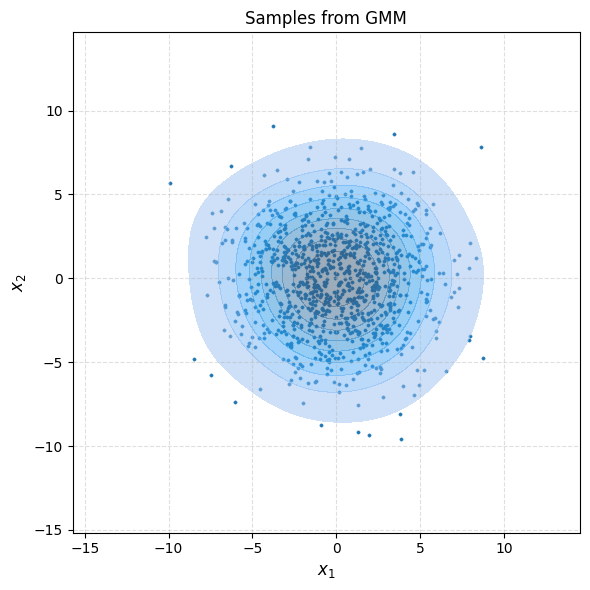

In [142]:
torch.manual_seed(SEED)
# 1) Dataset FIXE : X_0 = data
N = 100_000
batch_size = 256
N_components = 2
dim = 100

x0_all = torch.randn(N, dim) * 3.0 # data

dataset = TensorDataset(x0_all)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

####### Plot
fig, ax = plt.subplots(figsize=(6, 6))
df = pd.DataFrame({"x": x0_all[:1000, 0], "y": x0_all[:1000, 1]})
# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:blue", ax=ax
)

# KDE contour lines (few levels)
sns.kdeplot(
    data=df, x="x", y="y",
    levels=10,          # few contour lines
    thresh=0.05,
    color="tab:blue",
    linewidths=1.2,
    fill=True, alpha=0.5,
    bw_adjust=2,     # tune smoothness
    ax=ax
)

ax.set_title("Samples from GMM")
#ax.set_aspect("equal", adjustable="box")
plt.xlabel("$x_1$", fontsize=12)
plt.ylabel("$x_2$", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [143]:
torch.manual_seed(SEED)
flow = Flow(dim=100, h=128)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

# 2) Train : X_1 = prior (normal) resamplée à chaque batch
num_epochs = 50
for epoch in range(num_epochs):
    for (batch_x,) in loader:
        x1 = batch_x
        x0 = torch.randn_like(x1)         
        t = torch.rand(len(x1), 1, device=x1.device)

        # Chemin: x_t = (1-t) x0 + t x1
        x_t = (1 - t) * x0 + t * x1
        # Pour ce chemin linéaire, la vitesse cible est constante
        dx_t = x1 - x0

        optimizer.zero_grad()
        loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
        loss.backward()
        optimizer.step()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


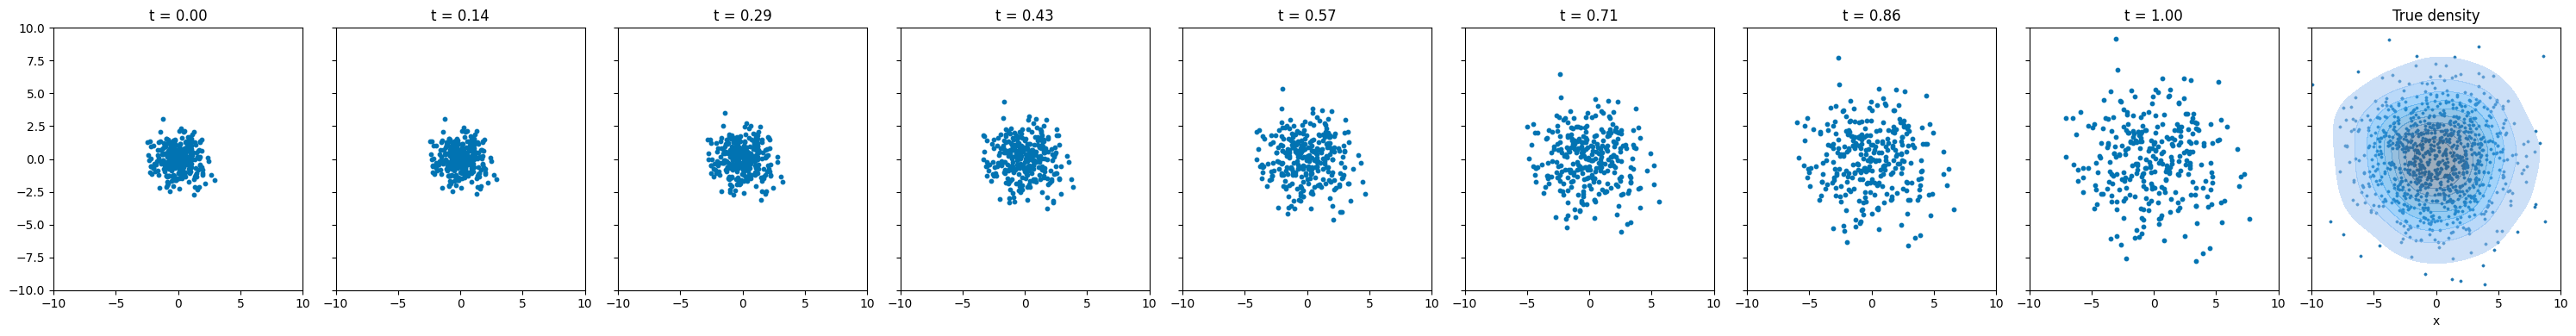

In [144]:
torch.manual_seed(SEED)
KDE_PLOT = True

x = torch.randn(300, 100)
n_steps = 7
fig, axes = plt.subplots(1, n_steps + 2, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

# True density
LIMIT = 1000

df = pd.DataFrame({"x": x0_all.detach()[:LIMIT, 0], "y": x0_all.detach()[:LIMIT, 1]})

# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:blue", ax=axes[-1]
)

if KDE_PLOT:
    # KDE contour lines (few levels)
    sns.kdeplot(
        data=df, x="x", y="y",
        levels=10,          # few contour lines
        thresh=0.05,
        color="tab:blue",
        linewidths=1.2,
        fill=True, alpha=0.5,
        bw_adjust=1.5,     # tune smoothness
        ax=axes[-1]
    )
axes[-1].set_title(f'True density')


plt.tight_layout()
plt.show()

In [145]:
import torch

def compute_jacobian(flow, t, x):
    x = x.detach().clone().requires_grad_(True)

    def flow_fn(x_):
        t_tensor = torch.tensor([t], dtype=x_.dtype, device=x_.device)
        return flow(t=t_tensor, x_t=x_)

    # jac: shape (out_dim, in_dim)
    jac = torch.autograd.functional.jacobian(flow_fn, x, create_graph=False)

    U, S, Vh = torch.linalg.svd(jac)
    return Vh, S, jac

Vh, S, jac = compute_jacobian(flow, t=0.5, x=torch.randn(100))
Vh

tensor([[-0.0714, -0.0313, -0.0945,  ..., -0.0276, -0.0404, -0.1332],
        [-0.0381, -0.0522,  0.0551,  ..., -0.1582, -0.0169, -0.1117],
        [ 0.0286, -0.1851, -0.0624,  ...,  0.0830,  0.0094,  0.1454],
        ...,
        [ 0.0256, -0.0204,  0.0892,  ...,  0.0971,  0.0790, -0.0300],
        [-0.0199,  0.2211, -0.0192,  ...,  0.1127, -0.1039, -0.1372],
        [-0.0055, -0.0689, -0.0767,  ..., -0.0282, -0.0144,  0.0976]])

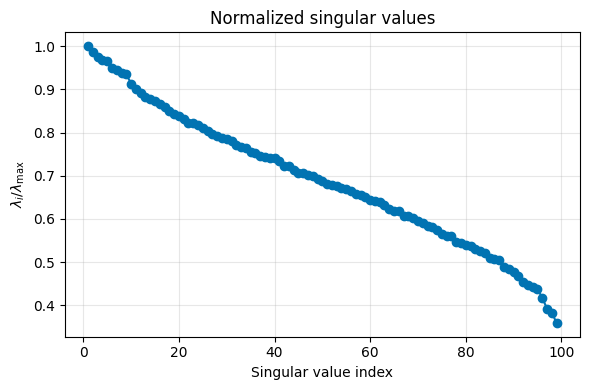

In [171]:
# unnormalized singular values
Vh, S, jac = compute_jacobian(flow, t=0.7, x=torch.randn(100))
S = S.detach().cpu()[1:]
S_norm = S / S.max()  # normalize by max singular value
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(S_norm) + 1), S_norm.numpy(), marker="o")
plt.xlabel("Singular value index")
plt.ylabel(r"$\lambda_i / \lambda_{\max}$")
plt.title("Normalized singular values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

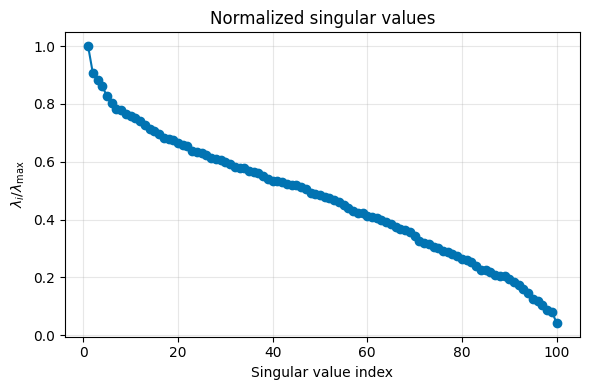

In [147]:
# unnormalized singular values
S = S_.detach().cpu()
S_norm = S / S.max()  # normalize by max singular value

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(S_norm) + 1), S_norm.numpy(), marker="o")
plt.xlabel("Singular value index")
plt.ylabel(r"$\lambda_i / \lambda_{\max}$")
plt.title("Normalized singular values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()